# Decision Tree Classifier — F1 Podium Prediction

Same train/test split as `knn.ipynb`, `svm.ipynb`, `linear_models.ipynb` so all five models are directly comparable on the combined ROC plot.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("../f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)

X = df[FEATURES].values
y = df['podium'].values

print(f"Dataset: {X.shape}")
print(f"Class balance:")
print(f"  No podium (0): {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print(f"  Podium    (1): {(y==1).sum()}  ({(y==1).mean()*100:.1f}%)")

Dataset: (5302, 4)
Class balance:
  No podium (0): 4393  (82.9%)
  Podium    (1): 909  (17.1%)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Train podium rate: {y_train.mean()*100:.1f}%")
print(f"Test  podium rate: {y_test.mean()*100:.1f}%")
print()
print("Note: Decision trees do NOT need feature scaling.")
print("They split on raw thresholds (e.g. 'grid <= 3.5'), so units don't matter.")

Train: (4241, 4)  Test: (1061, 4)
Train podium rate: 17.1%
Test  podium rate: 17.2%

Note: Decision trees do NOT need feature scaling.
They split on raw thresholds (e.g. 'grid <= 3.5'), so units don't matter.


## Hyperparameter search

Key knobs for a decision tree:
- **`max_depth`** — how deep the tree can grow. Small = high bias, large = high variance (overfit).
- **`min_samples_split`** — minimum samples needed in a node to consider splitting it.
- **`min_samples_leaf`** — minimum samples in a leaf.
- **`criterion`** — how the split quality is measured (`gini` or `entropy`).

We grid-search over these with 5-fold CV on ROC-AUC.

In [8]:
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5],
    'criterion':         ['gini', 'entropy']
}

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

grid_dt = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f"Best parameters : {grid_dt.best_params_}")
print(f"Best CV AUC     : {grid_dt.best_score_:.3f}")

Best parameters : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV AUC     : 1.000


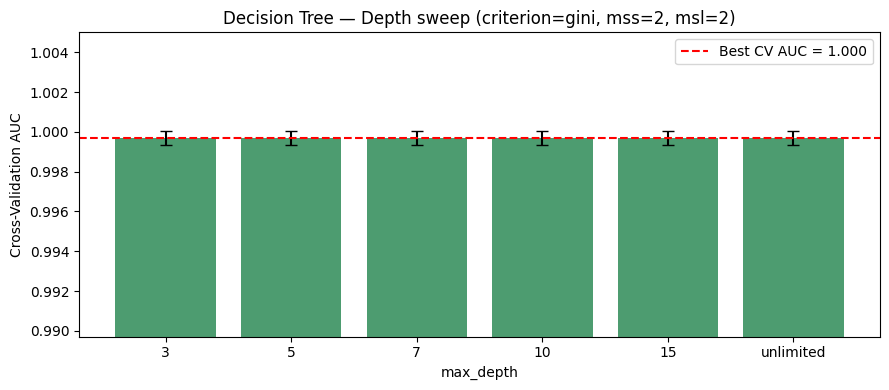

Saved: dt_depth_search.png


In [9]:
results = pd.DataFrame(grid_dt.cv_results_)

best_crit = grid_dt.best_params_['criterion']
best_mss  = grid_dt.best_params_['min_samples_split']
best_msl  = grid_dt.best_params_['min_samples_leaf']

slice_ = results[
    (results['param_criterion']         == best_crit) &
    (results['param_min_samples_split'] == best_mss)  &
    (results['param_min_samples_leaf']  == best_msl)
].copy()

def _depth_label(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return 'unlimited'
    return str(int(v))

slice_ = slice_.sort_values('mean_test_score', ascending=False)
depth_labels = [_depth_label(v) for v in slice_['param_max_depth']]
mean_scores  = slice_['mean_test_score'].to_numpy()
std_scores   = slice_['std_test_score'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(depth_labels, mean_scores,
       yerr=std_scores, color='seagreen',
       capsize=4, alpha=0.85)
ax.axhline(grid_dt.best_score_, linestyle='--', color='red',
           label=f'Best CV AUC = {grid_dt.best_score_:.3f}')
ax.set_xlabel("max_depth")
ax.set_ylabel("Cross-Validation AUC")
ax.set_title(f"Decision Tree — Depth sweep "
             f"(criterion={best_crit}, mss={best_mss}, msl={best_msl})")
ax.set_ylim([mean_scores.min() - 0.01, 1.005])
ax.legend()
plt.tight_layout()
plt.savefig("dt_depth_search.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dt_depth_search.png")

In [10]:
dt_final = grid_dt.best_estimator_

y_pred = dt_final.predict(X_test)
y_prob = dt_final.predict_proba(X_test)[:, 1]

print(f"=== Decision Tree (final) ===")
print(f"Best params : {grid_dt.best_params_}")
print(f"Tree depth  : {dt_final.get_depth()}")
print(f"# leaves    : {dt_final.get_n_leaves()}")
print(f"Accuracy    : {accuracy_score(y_test, y_pred)*100:.1f}%")

=== Decision Tree (final) ===
Best params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Tree depth  : 3
# leaves    : 5
Accuracy    : 99.9%


In [11]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=['No podium', 'Podium']))

=== Classification Report ===
              precision    recall  f1-score   support

   No podium       1.00      1.00      1.00       879
      Podium       0.99      1.00      1.00       182

    accuracy                           1.00      1061
   macro avg       1.00      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



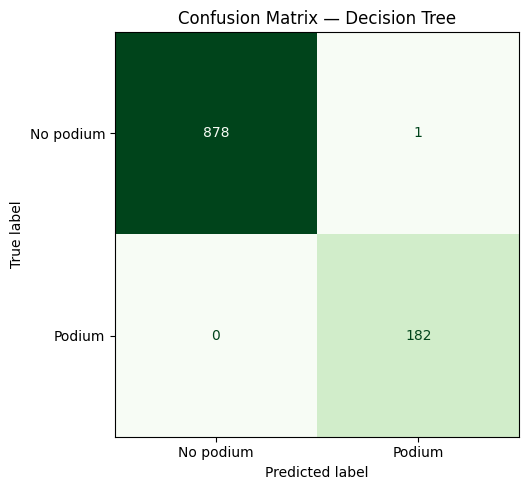

True Negatives  (TN): 878  — correctly predicted NO podium
False Positives (FP): 1  — predicted podium, was wrong
False Negatives (FN): 0  — missed actual podium finishes
True Positives  (TP): 182  — correctly predicted podium


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No podium', 'Podium']
                       ).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.savefig("dt_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — correctly predicted NO podium")
print(f"False Positives (FP): {fp}  — predicted podium, was wrong")
print(f"False Negatives (FN): {fn}  — missed actual podium finishes")
print(f"True Positives  (TP): {tp}  — correctly predicted podium")

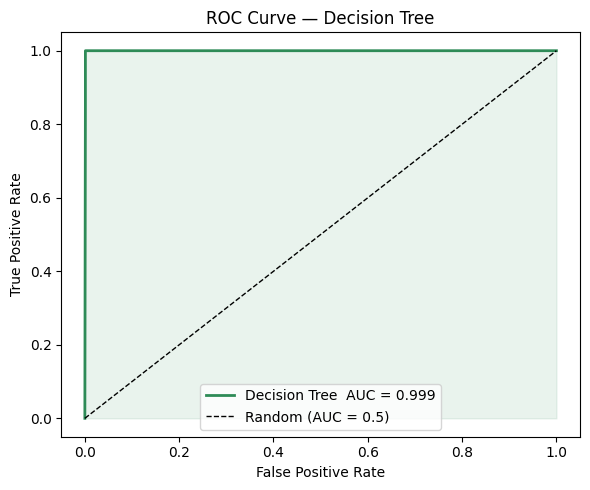

AUC Score: 0.999


In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='seagreen', linewidth=2,
        label=f'Decision Tree  AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='seagreen')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Decision Tree")
ax.legend()
plt.tight_layout()
plt.savefig("dt_roc.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc:.3f}")

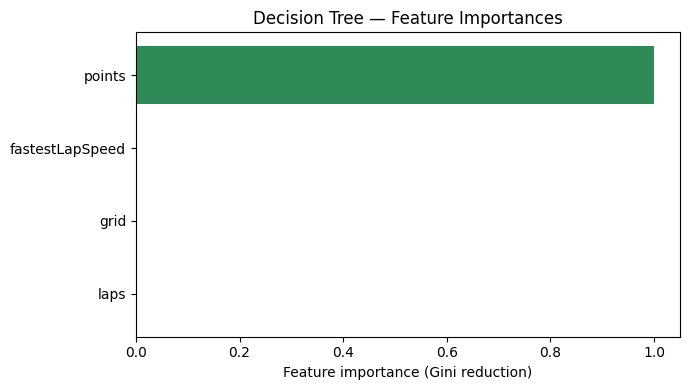

=== Feature importances ===
        Feature  Importance
         points    0.999901
fastestLapSpeed    0.000080
           grid    0.000019
           laps    0.000000


In [14]:
importances = dt_final.feature_importances_

imp_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='seagreen')
ax.set_xlabel("Feature importance (Gini reduction)")
ax.set_title("Decision Tree — Feature Importances")
plt.tight_layout()
plt.savefig("dt_importances.png", dpi=150, bbox_inches='tight')
plt.show()

print("=== Feature importances ===")
print(imp_df.sort_values('Importance', ascending=False).to_string(index=False))

## Visualize the tree

One thing decision trees give us that KNN/SVM/LR don't: a fully readable rule structure. We plot the **top 3 levels** so the figure stays readable — the full tree can be very large.

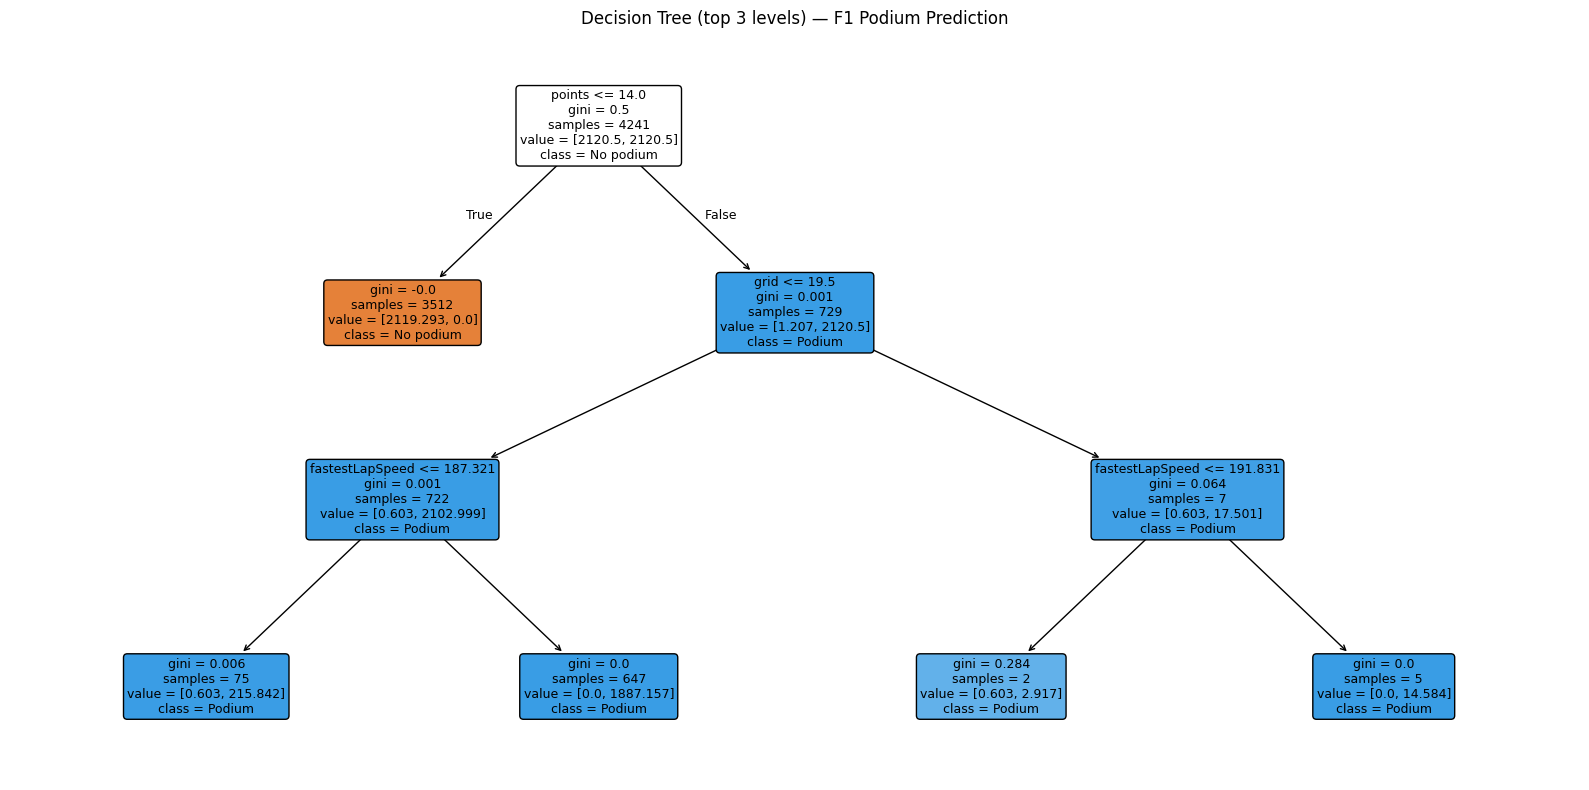

Saved: dt_tree.png


In [15]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    dt_final,
    max_depth=3,
    feature_names=FEATURES,
    class_names=['No podium', 'Podium'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Decision Tree (top 3 levels) — F1 Podium Prediction")
plt.tight_layout()
plt.savefig("dt_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dt_tree.png")

In [16]:
np.save("dt_y_prob.npy", y_prob)
print("Saved: dt_y_prob.npy  ← used by linear_models.ipynb for the combined ROC")

Saved: dt_y_prob.npy  ← used by linear_models.ipynb for the combined ROC


In [17]:
print("=== Decision Tree Final Results ===")
print(f"Best params : {grid_dt.best_params_}")
print(f"Tree depth  : {dt_final.get_depth()}")
print(f"# leaves    : {dt_final.get_n_leaves()}")
print(f"Accuracy    : {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"AUC Score   : {roc_auc_score(y_test, y_prob):.3f}")
print()
print("Key properties of Decision Trees:")
print("  - Non-parametric — no assumption about data distribution")
print("  - No feature scaling required (split on raw thresholds)")
print("  - Fully interpretable: every prediction is a sequence of if/else rules")
print("  - Gives feature importances out of the box")
print("  - High variance if unrestricted (overfits easily)")
print("  - Pruning via max_depth / min_samples_* fights overfitting")

=== Decision Tree Final Results ===
Best params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Tree depth  : 3
# leaves    : 5
Accuracy    : 99.9%
AUC Score   : 0.999

Key properties of Decision Trees:
  - Non-parametric — no assumption about data distribution
  - No feature scaling required (split on raw thresholds)
  - Fully interpretable: every prediction is a sequence of if/else rules
  - Gives feature importances out of the box
  - High variance if unrestricted (overfits easily)
  - Pruning via max_depth / min_samples_* fights overfitting
